## Authorship

- **Course / code author:** Xinze Li  
- **Tutorial article:** Xinze Li, Fanfan Lin, Juan J. Rodríguez-Andina, Sergio Vazquez, Homer Alan Mantooth, Leopoldo García Franquelo, "Fundamentals of Artificial Intelligences for Power Electronics," *IEEE Transactions on Industrial Electronics*, 2026.

*These learning resources are still under active refinement; notebooks, data, and documentation may change.*

---



#### Core Loss Modeling of Magnetic Components
* Dataset source: Princeton University - MagNet Challenge, https://www.princeton.edu/~minjie/magnet.html
* This dataset is a downsampled version (one material, reduced data) for a quick illustration
* Inputs include hybrid signal-domain (B waveform) and tabular data (frequency, temperature), the output is tabular
* B waveforms are converted to tabular harmonics, and so the inputs become all tabular
* Model: Feedforward NN

#### 1 Load Data
* The output is converted using logarithm transform to get closer to Gaussian distribution

In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Load the downscaled files
waveforms = np.loadtxt("B_waveform[T]_downscaled.csv", delimiter=",")
frequencies = np.loadtxt("Frequency[Hz]_downscaled.csv", delimiter=",")
temperatures = np.loadtxt("Temperature[C]_downscaled.csv", delimiter=",")
volumetric_losses = np.loadtxt("Volumetric_losses[Wm-3]_downscaled.csv", delimiter=",")

# Basic shape assertions and reshaping for consistency
num_waveforms, seq_len = waveforms.shape
print(f"Number of waveforms (downscaled): {num_waveforms}")
print(f"Sequence length: {seq_len}")

if frequencies.ndim == 1:
    frequencies = frequencies.reshape(-1, 1)
if temperatures.ndim == 1:
    temperatures = temperatures.reshape(-1, 1)
if volumetric_losses.ndim == 1:
    volumetric_losses = volumetric_losses.reshape(-1, 1)

# Parameter: number of harmonics to extract (excluding DC)
num_harmonics = 13  # must match with future harmonics calculation if done

# Compute the FFT for each waveform using the corresponding frequency for each sample
# The frequency in "Frequency[Hz].csv" is the fundamental frequency for each waveform
harmonic_magnitudes = np.zeros((waveforms.shape[0], num_harmonics))

for i in range(waveforms.shape[0]):
    waveform = waveforms[i]
    freq = frequencies[i, 0]  # fundamental frequency in Hz
    n = len(waveform)
    # FFT
    fft_result = np.fft.rfft(waveform)
    fft_magnitude = np.abs(fft_result) / n * 2  # scale for amplitude (except DC)
    # Frequency bins for this waveform
    sample_rate = freq * n  # If one period is sampled, sample_rate = freq * n / period_length, but assume n samples per period
    freqs = np.fft.rfftfreq(n, d=1.0/(freq * n))
    # The k-th harmonic is at k * fundamental frequency
    for k in range(1, num_harmonics + 1):
        harmonic_freq = k * freq
        # Find the closest bin to the harmonic frequency
        idx = np.argmin(np.abs(freqs - harmonic_freq))
        harmonic_magnitudes[i, k-1] = fft_magnitude[idx]

# Prepare the input feature matrix: [harmonic magnitudes | frequency | temperature]
X_full = np.hstack([harmonic_magnitudes, frequencies, temperatures])  # shape: (num_waveforms, num_harmonics+2)
y = volumetric_losses

# Calculate log(y) for distribution plots and stratification, if desired
epsilon = 1e-12
y_log = np.log(y.flatten() + epsilon)

print(f"Downsampled waveforms shape: {waveforms.shape}")
print(f"Downsampled input features shape: {X_full.shape}")
print(f"Downsampled output variable y shape: {y.shape}")

Number of waveforms (downscaled): 3257
Sequence length: 1024
Downsampled waveforms shape: (3257, 1024)
Downsampled input features shape: (3257, 15)
Downsampled output variable y shape: (3257, 1)


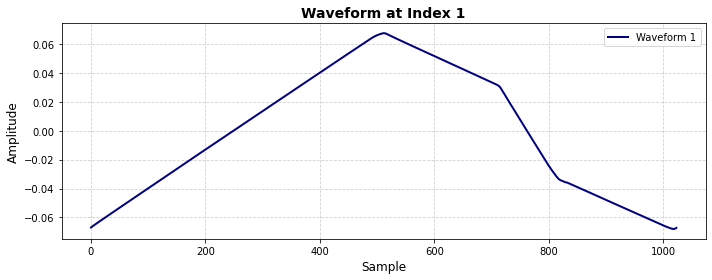

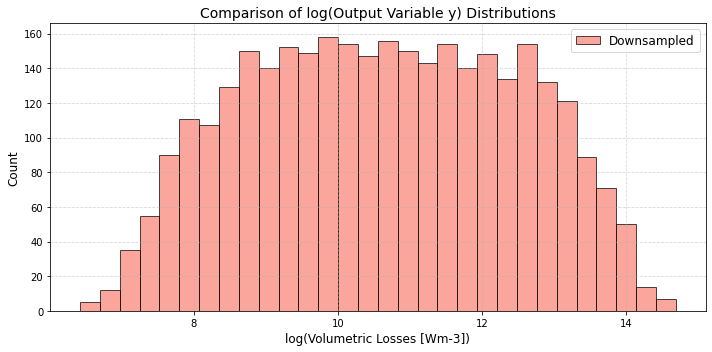

In [2]:
# Basic Data Visualization
import numpy as np
import matplotlib.pyplot as plt

def plot_waveform(index):
    """
    Plot the waveform at the specified index from the waveforms array.
    """
    if not (0 <= index < waveforms.shape[0]):
        print(f"Index {index} is out of bounds (0, {waveforms.shape[0] - 1})")
        return

    plt.figure(figsize=(10, 4))
    plt.plot(
        waveforms[index],
        color='navy',
        linewidth=2,
        label=f'Waveform {index}'
    )
    plt.title(f"Waveform at Index {index}", fontsize=14, fontweight='bold')
    plt.xlabel("Sample", fontsize=12)
    plt.ylabel("Amplitude", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()

index = 1
plot_waveform(index)

# Compare the distribution of the original and downsampled datasets
plt.figure(figsize=(10, 5))
plt.hist(y_log, bins=30, color='salmon', edgecolor='black', alpha=0.7, label='Downsampled')
plt.title("Comparison of log(Output Variable y) Distributions", fontsize=14)
plt.xlabel("log(Volumetric Losses [Wm-3])", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 2 Data Partition, Preprocessing, and Define PyTorch DataLoader
---
2.1 Data Partition:
- The code for partitioning the data (train/validation/test split) is fixed and should not be modified.

**2.2 Data Preprocessing Strategies:**

    - You may apply various data preprocessing techniques (e.g., `StandardScaler`, etc.).
- For more details, refer to the [scikit-learn preprocessing documentation](https://scikit-learn.org/stable/modules/preprocessing.html).

**2.3 Define PyTorch DataLoader:**
- Batch size for the training set dataloader might affect the NN accuracy, and can be tuned.
---

In [3]:
# Data Partition
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch
from torch.utils.data import TensorDataset
import numpy as np

# Partition the data: train/val/test (60/20/20) -- as in file_context_0
X_temp, X_test, y_temp, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2


# Data Preprocessing Strategies

# Apply data preprocessing techniques (e.g., `StandardScaler`, etc.)
# Standardize input features using training set statistics
input_scaler = StandardScaler()
X_train_scaled = input_scaler.fit_transform(X_train)
X_val_scaled = input_scaler.transform(X_val)
X_test_scaled = input_scaler.transform(X_test)
# Apply MinMaxScaler to output (fit only on training set)
epsilon = 1e-12  # To avoid log(0)
output_scaler = MinMaxScaler()

# Apply log transform then MinMax scaling to outputs (fit only on training set)
y_train_log = np.log(y_train + epsilon)
y_val_log = np.log(y_val + epsilon)
y_test_log = np.log(y_test + epsilon)

y_train_scaled = output_scaler.fit_transform(y_train_log.reshape(-1, 1))
y_val_scaled = output_scaler.transform(y_val_log.reshape(-1, 1))
y_test_scaled = output_scaler.transform(y_test_log.reshape(-1, 1))

In [4]:
# Define PyTorch DataLoader
from torch.utils.data import DataLoader

# Convert to PyTorch tensors and create TensorDatasets
train_set = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), torch.tensor(y_train_scaled, dtype=torch.float32))
val_set = TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32), torch.tensor(y_val_scaled, dtype=torch.float32))
test_set = TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32), torch.tensor(y_test_scaled, dtype=torch.float32))

# Tune the batch size for the training set dataloader
batch_size = 500
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

## 3 Core Loss Modeling for Magnetic Material 3C90: Define Feedforward Neural Networks
---
**3.1 Define Neural Network Structure:**

    - Vanilla feedforward NN is defined as default - Feel free to use more advanced activation/layers/architectures
- Layers: BatchNorm/LayerNorm, dropout, residual, convolutional, recurrent, attention, etc.
- Activation: SiLU, GLU, Sigmoid, Tanh, etc.

**3.2 Tune Neural Network Structure:**

    - Number of hidden layers, and number of hidden units inside each layer can be adjusted
---

In [5]:
# Define Neural Network Structure
import torch
import torch.nn as nn

# 3. Model definition: Fully connected, batch-norm, parameterized hidden layers, z-score weights during training
class FeedforwardNN(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, out_dim=1, num_hidden_layers=2):
        super().__init__()
        layers = []
        # Input layer
        layers.append(nn.Linear(in_dim, hidden_dim))
        # layers.append(nn.BatchNorm1d(hidden_dim))
        layers.append(nn.ReLU())
        # Hidden layers
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            # layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
        # Output layer
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def zscore_weights(model):
    # Z-score (standardize) all weights and biases in-place
    with torch.no_grad():
        for name, param in model.named_parameters():
            if param.requires_grad and param.data.ndimension() > 0:
                mean = param.data.mean()
                std = param.data.std()
                if std > 0:
                    param.data.sub_(mean).div_(std)
                else:
                    param.data.sub_(mean)

In [6]:
# Tune Neural Network Structure

# Training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
in_dim = X_full.shape[1]
hidden_dim = 64  # You can change this to parameterize hidden_dim
out_dim = y.shape[1]
num_hidden_layers = 2  # You can change this to parameterize number of hidden layers

# Tune the number of hidden layers and hidden units
model = FeedforwardNN(in_dim, hidden_dim, out_dim, num_hidden_layers).to(device)
criterion = nn.MSELoss()

## 4 Core Loss Modeling for Magnetic Material 3C90: Train Feedforward Neural Networks
---
**4.1 Define Optimization Algorithm and/or Scheduler:**

    - AdamW optimizer with a constant learning rate is used as default. Feel free to use more other optimizers and/or schedulers
- Optimizers: Adam, AdamW, SparseAdam, Adamax, LBFGS, RMSprop, etc.
- Schedulers: StepLR, ReduceLROnPlateau, LinearLR, CyclicLR, etc.
- For more details, refer to the [pytorch optim documentation](https://docs.pytorch.org/docs/stable/optim.html).

**4.2 Define and Implement Training Loop:**
- As default, the validation set is not used during training.
- You can consider to use validation set to avoid overfitting.
- Training epoch is an important hyper-parameter to tune.
---

In [7]:
# Define Optimization Algorithm and/or Scheduler

import torch

# Default optimizer: Adam with a constant learning rate
# Tune the learning rate or use other optimizers or use learning rate scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.8)  # Anneal every 50 epochs

In [8]:
# Define and Implement Training Loop
import torch
import numpy as np
import copy

# Training phase
num_epochs = 3000
best_val_loss = float('inf')
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        # Z-score weights after each batch
        # zscore_weights(model)
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    # Use validation loss for early stopping and to avoid overfitting
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    # Update learning rate if you have added learning rate scheduler
    # Only step the scheduler if the learning rate is >= 1e-4
    current_lr = optimizer.param_groups[0]['lr']
    if current_lr >= 1e-4:
        scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

    if (epoch+1) % 20 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.5f} - Val Loss: {val_loss:.5f} - LR: {current_lr:.6f}")

# If you have used early stopping and to avoid overfitting, load the best model weights (on validation set)
# Load best model
model.load_state_dict(best_model_state)

Epoch 1/3000 - Train Loss: 0.12193 - Val Loss: 0.04336 - LR: 0.002000
Epoch 20/3000 - Train Loss: 0.00308 - Val Loss: 0.00315 - LR: 0.002000
Epoch 40/3000 - Train Loss: 0.00093 - Val Loss: 0.00110 - LR: 0.002000
Epoch 60/3000 - Train Loss: 0.00053 - Val Loss: 0.00062 - LR: 0.001600
Epoch 80/3000 - Train Loss: 0.00037 - Val Loss: 0.00042 - LR: 0.001600
Epoch 100/3000 - Train Loss: 0.00028 - Val Loss: 0.00032 - LR: 0.001600
Epoch 120/3000 - Train Loss: 0.00020 - Val Loss: 0.00028 - LR: 0.001280
Epoch 140/3000 - Train Loss: 0.00018 - Val Loss: 0.00024 - LR: 0.001280
Epoch 160/3000 - Train Loss: 0.00013 - Val Loss: 0.00021 - LR: 0.001024
Epoch 180/3000 - Train Loss: 0.00012 - Val Loss: 0.00019 - LR: 0.001024
Epoch 200/3000 - Train Loss: 0.00010 - Val Loss: 0.00018 - LR: 0.001024
Epoch 220/3000 - Train Loss: 0.00010 - Val Loss: 0.00017 - LR: 0.000819
Epoch 240/3000 - Train Loss: 0.00009 - Val Loss: 0.00017 - LR: 0.000819
Epoch 260/3000 - Train Loss: 0.00008 - Val Loss: 0.00016 - LR: 0.00065

<All keys matched successfully>

## 5 Model Evaluation: Accuracy and Size
---
5.1 Evaluate Model Accuracy:
- Evaluate and export model accuracy.

5.2 Evaluate Model Size:
- Evaluate and export model size.

5.3 Plot and Visualize Results:
- Visualize the accuracy
---

In [9]:
# Evaluate Model Accuracy

import pandas as pd

def evaluate_model_accuracy(loader, scaler_y, model, device, set_name="Set"):
    """
    Evaluates the regression performance of the model on a given dataset loader.

    Args:
        loader: DataLoader for the dataset.
        scaler_y: Scaler used for the target variable (output_scaler).
        model: Trained model.
        device: Device to run the model on.
        set_name (str): Name of the dataset (for display purposes).

    Returns:
        mae (float): Mean Absolute Error.
        rmse (float): Root Mean Squared Error.
        mape (float): Mean Absolute Percentage Error.
        size (int): Number of samples in the dataset.
        y_true (np.ndarray): True target values (original scale).
        y_pred (np.ndarray): Predicted target values (original scale).
    """
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            preds = model(xb).cpu().numpy()
            y_pred.append(preds)
            y_true.append(yb.cpu().numpy())
    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)
    # Inverse transform to original y scale (log + minmax)
    y_true_log = scaler_y.inverse_transform(y_true)
    y_pred_log = scaler_y.inverse_transform(y_pred)
    y_true_orig = np.exp(y_true_log)
    y_pred_orig = np.exp(y_pred_log)
    mae = np.mean(np.abs(y_true_orig - y_pred_orig))
    rmse = np.sqrt(np.mean((y_true_orig - y_pred_orig) ** 2))
    # Compute MAPE, avoid division by zero
    epsilon = 1e-8
    mape = np.mean(np.abs((y_true_orig - y_pred_orig) / (y_true_orig + epsilon))) * 100
    size = y_true_orig.shape[0]
    return mae, rmse, mape, size, y_true_orig, y_pred_orig

# Evaluate the regression model on train, val, and test sets
model.eval()

results = []

# Train set
train_mae, train_rmse, train_mape, train_size, y_train_true, y_train_pred = evaluate_model_accuracy(
    train_loader, output_scaler, model, device, set_name="Train Set"
)
results.append({
    "Set": "Train",
    "Size": train_size,
    "MAE": train_mae,
    "RMSE": train_rmse,
    "MAPE (%)": train_mape
})

# Validation set
val_mae, val_rmse, val_mape, val_size, y_val_true, y_val_pred = evaluate_model_accuracy(
    val_loader, output_scaler, model, device, set_name="Validation Set"
)
results.append({
    "Set": "Validation",
    "Size": val_size,
    "MAE": val_mae,
    "RMSE": val_rmse,
    "MAPE (%)": val_mape
})

# Test set
test_mae, test_rmse, test_mape, test_size, y_test_true, y_test_pred = evaluate_model_accuracy(
    test_loader, output_scaler, model, device, set_name="Test Set"
)
results.append({
    "Set": "Test",
    "Size": test_size,
    "MAE": test_mae,
    "RMSE": test_rmse,
    "MAPE (%)": test_mape
})

# Create a DataFrame to store the results
metrics_df = pd.DataFrame(results, columns=["Set", "Size", "MAE", "RMSE", "MAPE (%)"])
print("\n=== REGRESSION METRICS SUMMARY TABLE ===")
print(metrics_df)


=== REGRESSION METRICS SUMMARY TABLE ===
          Set  Size           MAE          RMSE  MAPE (%)
0       Train  1953   2818.994873   6446.086426  2.487600
1  Validation   652  11548.980469  31696.054688  6.184674
2        Test   652  17134.171875  64477.027344  6.259163


In [10]:
# Evaluate Model Size and Save Results

import pickle

# Evaluate and print the number of parameters in the model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

num_params = count_parameters(model)
print(f"\n=== REGRESSION MODEL SIZE ===")
print(f"Number of trainable parameters: {num_params}")


=== REGRESSION MODEL SIZE ===
Number of trainable parameters: 5249


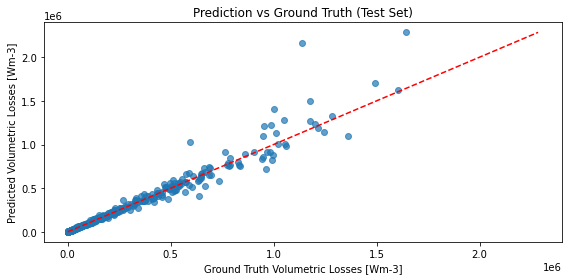

In [11]:
# Plot and Visualize Results
import matplotlib.pyplot as plt

# Use already computed y_test_true and y_test_pred from Block 5-1
plt.figure(figsize=(8, 4))
plt.scatter(y_test_true, y_test_pred, alpha=0.7)
min_val = min(y_test_true.min(), y_test_pred.min())
max_val = max(y_test_true.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel("Ground Truth Volumetric Losses [Wm-3]")
plt.ylabel("Predicted Volumetric Losses [Wm-3]")
plt.title("Prediction vs Ground Truth (Test Set)")
plt.tight_layout()
plt.show()